In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit

os.chdir('/home/onyxia/work/bdc-apicil-g1')

from src.model import FEATURES, split_data, evaluate, save_model

In [2]:
df = pd.read_csv('data/processed/panel_final.csv')
print(f'{len(df):,} observations, {df.shape[1]} colonnes')

/tmp/ipykernel_55854/3958595456.py:1: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('data/processed/panel_final.csv')


1,383,526 observations, 133 colonnes


Train : 1,001,183 observations (2.40% de résiliations)
Test  : 382,343 observations (1.75% de résiliations)

Modèle : XGBClassifier
AUC-ROC   : 0.9453  — aire sous la courbe ROC
AUC-PR    : 0.2224  — aire sous la courbe Précision-Recall (plus fiable avec classes déséquilibrées)
Recall    : 0.7929  — taux de résiliants détectés
Précision : 0.1931  — part de vrais résiliants parmi les alertes
F1        : 0.3106  — équilibre recall/précision
F2        : 0.4891  — pénalise davantage les faux négatifs
MCC       : 0.3726  — robuste au déséquilibre des classes
Brier     : 0.0506  — calibration des probabilités (plus bas = mieux)

              precision    recall  f1-score   support

           0       1.00      0.94      0.97    375637
           1       0.19      0.79      0.31      6706

    accuracy                           0.94    382343
   macro avg       0.59      0.87      0.64    382343
weighted avg       0.98      0.94      0.96    382343



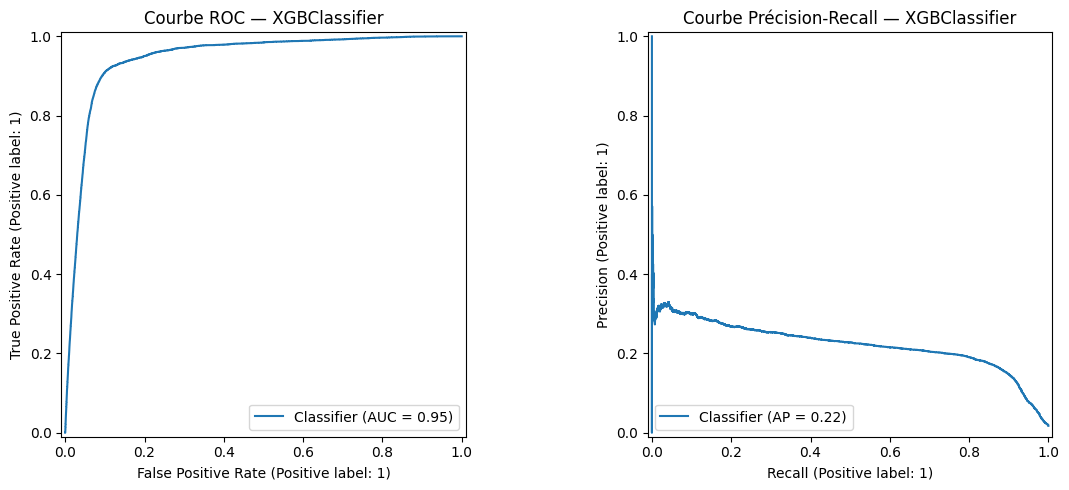

Modèle sauvegardé dans models/xgboost_insee.pkl


'models/xgboost_insee.pkl'

In [ ]:
x_train, x_test, y_train, y_test = split_data(df)

ratio = (y_train == 0).sum() / (y_train == 1).sum()

best_model = XGBClassifier(
    scale_pos_weight=ratio,
    n_estimators=300,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.7,
    colsample_bytree=1.0,
    min_child_weight=1,
    gamma=0,
    random_state=42,
    n_jobs=-1,
    eval_metric='auc',
)

best_model.fit(x_train, y_train)
metrics = evaluate(best_model, x_test, y_test)
save_model(best_model, 'xgboost_insee')

In [16]:
x_test["mois"]

1001183     1
1001184     1
1001185     1
1001186     1
1001187     1
           ..
1383521    12
1383522    12
1383523    12
1383524    12
1383525    12
Name: mois, Length: 382343, dtype: int64

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report,roc_auc_score,roc_curve,auc, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC

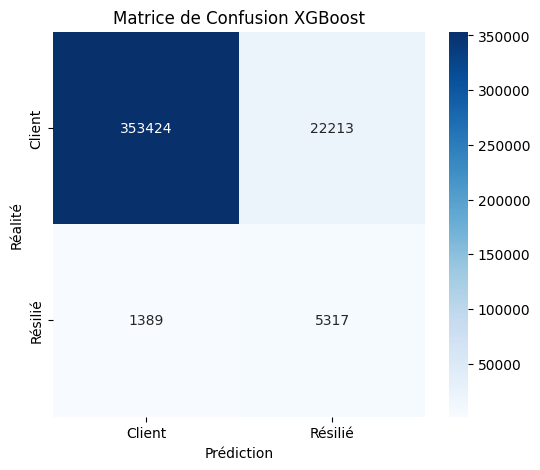

In [26]:
# On récupère les probabilités pour l'AUC
# Tu remplaces par ton modèle youssef
y_probs = best_model.predict_proba(x_test)[:, 1]
y_pred = best_model.predict(x_test)

# Matrice de confusion

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Client', 'Résilié'], yticklabels=['Client', 'Résilié'])
plt.title('Matrice de Confusion XGBoost')
plt.ylabel('Réalité')
plt.xlabel('Prédiction')
plt.show()

In [22]:
x_test = x_test.drop(columns=["mois"])

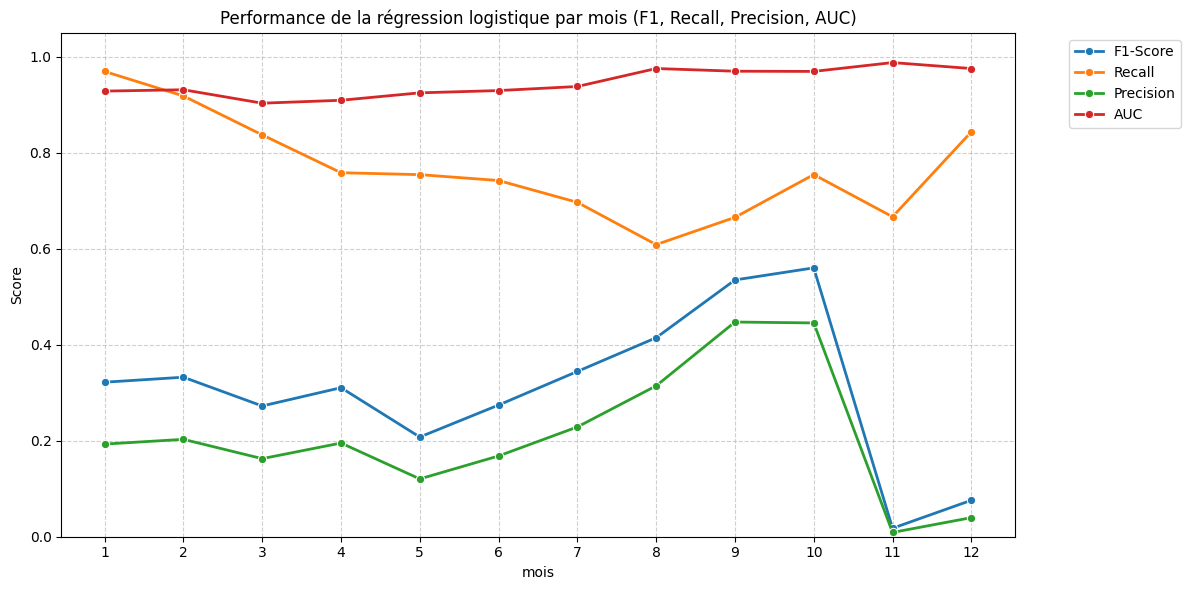

In [28]:

test  = df[df["date_reference"].dt.year >= 2025]

x_test_graph = x_test
x_test_graph['mois'] = test['mois_reference']

from sklearn.metrics import f1_score, recall_score, roc_auc_score, precision_score
import matplotlib.pyplot as plt
import seaborn as sns

results_by_month = []
x_test = x_test.drop(columns=["mois"])
# On récupère les probabilités pour l'AUC
# Tu remplaces par ton modèle youssef
y_probs = best_model.predict_proba(x_test)[:, 1]
y_pred = best_model.predict(x_test)


for m in sorted(x_test_graph['mois'].unique()):
    mask = (x_test_graph['mois'] == m)
    if mask.any():
        # Extraction des données du mois
        y_true_month = y_test[mask]
        y_pred_month = y_pred[mask]
        y_prob_month = y_probs[mask]
        
        # Calcul des métriques
        f1 = f1_score(y_true_month, y_pred_month)
        rec = recall_score(y_true_month, y_pred_month)
        prec = precision_score(y_true_month, y_pred_month) # Nouvelle métrique

        try:
            auc = roc_auc_score(y_true_month, y_prob_month)
        except ValueError:
            auc = np.nan

        results_by_month.append({
            'mois': m, 
            'F1-Score': f1, 
            'Recall': rec, 
            'Precision': prec,
            'AUC': auc
        })


df_perf_mois = pd.DataFrame(results_by_month)

# --- Affichage graphique ---
df_melted = df_perf_mois.melt(id_vars='mois', var_name='Métrique', value_name='Score')

plt.figure(figsize=(12, 6))
sns.lineplot(data=df_melted, x='mois', y='Score', hue='Métrique', marker='o', linewidth=2)

plt.title('Performance de la régression logistique par mois (F1, Recall, Precision, AUC)')
plt.ylim(0, 1.05)
plt.xticks(range(1, 13))
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


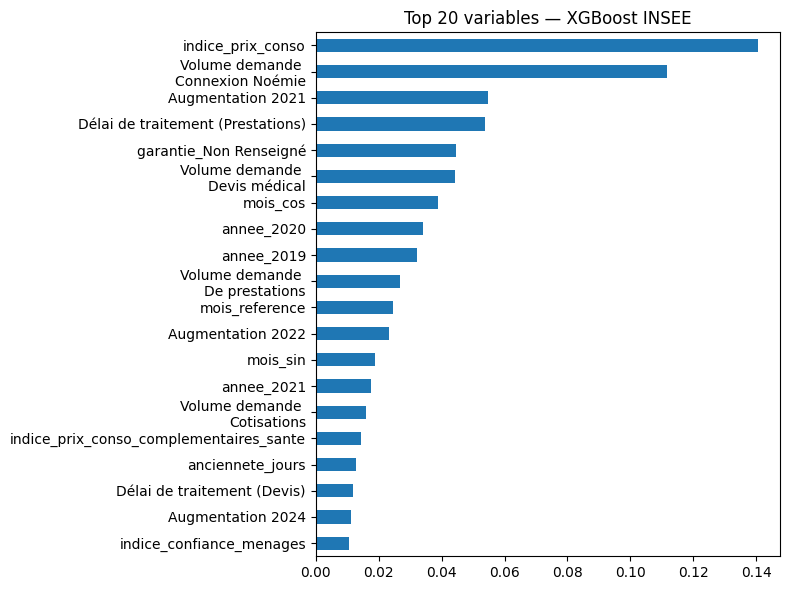

In [4]:
importances = pd.Series(best_model.feature_importances_, index=FEATURES)
importances.sort_values(ascending=False).head(20).plot(
    kind='barh', figsize=(8, 6)
)
plt.title('Top 20 variables — XGBoost INSEE')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()